In [2]:
import numpy as np
import pandas as pd



In [3]:
np.random.seed(23) 


In [4]:
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

In [5]:
df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

In [6]:
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)


In [7]:
df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])


In [8]:
df1['target'] = 0


In [11]:
df = pd.concat([df, df1], ignore_index=True)


In [12]:
df = df.sample(40)


In [13]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [ ]:

import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()


In [15]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [16]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [17]:
# Step 3 - Finding EV and EVs 
eigen_values , eigen_vectors = np.linalg.eig(covariance_matrix)

In [18]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [19]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

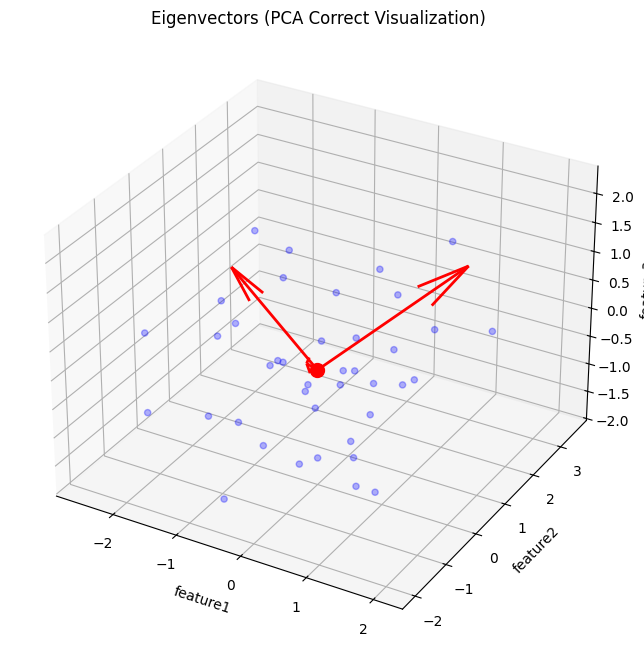

In [29]:
%matplotlib inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# ---- DATA ----
features = df[['feature1', 'feature2', 'feature3']]

# ---- PCA ----
pca = PCA(n_components=3)
pca.fit(features)

eigen_vectors = pca.components_
eigen_values = pca.explained_variance_
mean = pca.mean_

# ---- PLOT ----
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# data points
ax.scatter(df['feature1'], df['feature2'], df['feature3'],
           color='blue', alpha=0.3)

# mean point
ax.scatter(mean[0], mean[1], mean[2],
           color='red', s=100)

# ---- PCA AXES (IMPORTANT FIX) ----
scale = 2  # keep small like tutorial

for i in range(3):
    v = eigen_vectors[i]

    ax.quiver(
        mean[0], mean[1], mean[2],
        v[0] * eigen_values[i] * scale,
        v[1] * eigen_values[i] * scale,
        v[2] * eigen_values[i] * scale,
        color='red',
        linewidth=2
    )

# ---- LABELS ----
ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

plt.title("Eigenvectors (PCA Correct Visualization)")
plt.show()

In [31]:
pc = eigen_vectors[0:2]
pc

array([[ 0.53875915,  0.65608325,  0.52848211],
       [-0.69363291, -0.01057596,  0.72025103]])

In [35]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40 , 3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-2.302877,-0.757593,1
1,-0.524464,0.520221,0
2,-0.380275,-0.459443,1
3,-0.534262,-1.773773,1
4,-1.610434,1.747819,1


In [38]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()